# Clase 23 — Datos, sesgos y cómo aprende una IA

**Diplomado IA Aplicada al Diseño · UDD · 2026** · Prof. Darío Osorio

Ejecuta las celdas en orden. Donde diga `# TU TURNO`, modifica lo indicado.

## Objetivos del notebook
1. Cargar y explorar un dataset real (reseñas en español).
2. Detectar visualmente balance de clases y valores faltantes.
3. Identificar un sesgo posible.

**Archivos necesarios**: `Clase_23_dataset_resenas_es.csv` (súbelo a Colab junto con este notebook, ver Paso 1).

## Paso 0 — Instalación


In [34]:
!pip install -q pandas matplotlib seaborn
print("Listo.")

Listo.


## Paso 1 — Subir y cargar el dataset

Este notebook usa un dataset local (`Clase_23_dataset_resenas_es.csv`), preparado por el profesor: 1000+ reseñas de productos en español, con distribución realista (desbalanceada) y algunos valores faltantes / duplicados a propósito, para que los detectes tú.

Antes de ejecutar la siguiente celda: `Archivo → Subir cuaderno` ya lo hiciste; ahora sube también el CSV con el ícono de carpeta (📁) a la izquierda → `Subir a almacenamiento de sesión` → selecciona `Clase_23_dataset_resenas_es.csv`.

In [45]:
import pandas as pd

# Dataset local (no depende de descargas externas ni de conexión inestable en vivo)
df = pd.read_csv("base_datos_veterinaria_ampliada_con_resenas.csv")

print(f"Cargadas {len(df)} filas")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Cargadas 300 filas
Columnas disponibles: ['id_cita', 'id_mascota', 'id_veterinario', 'fecha', 'hora', 'motivo', 'estado', 'id_cliente', 'nombre_x', 'especie', 'raza', 'fecha_nacimiento', 'sexo', 'peso_kg', 'nombre_y', 'apellido_mascota_dueno', 'telefono_mascota_dueno', 'email', 'direccion', 'nombre', 'apellido_vet', 'especialidad', 'telefono_vet', 'nota_atencion', 'resena']


,id_cita,id_mascota,id_veterinario,fecha,hora,motivo,estado,id_cliente,nombre_x,especie,...,apellido_mascota_dueno,telefono_mascota_dueno,email,direccion,nombre,apellido_vet,especialidad,telefono_vet,nota_atencion,resena
0,1001,108,2,2026-09-15,16:00,Chequeo general,Programada,98,Zeus,Perro,...,Araya,56959529086,francisca.araya61@email.com,"Calle Vargas #8798, La Reina",María,Fernández,Cirugía y Traumatología,56933334444,NaN,Sin reseña registrado (cita no completada/pend...
1,1079,131,2,2026-07-05,15:15,Alergia en la piel,Completada,54,Bella,Perro,...,Mendoza,56973174945,felipe.mendoza29@email.com,"Calle Fernández #7641, La Reina",María,Fernández,Cirugía y Traumatología,56933334444,5.0,"Atención rápida, eficiente y muy empática. Tot..."
2,1063,148,2,2026-05-04,14:15,Vacunación Anual,Completada,60,Bugs,Exótico,...,Pérez,56919391725,roberto.perez86@email.com,"Calle Muñoz #5243, Ñuñoa",María,Fernández,Cirugía y Traumatología,56933334444,1.0,Servicio deficiente y costos excesivos para la...
3,1006,215,2,2026-09-19,13:45,Alergia en la piel,Programada,75,Fiona,Gato,...,Muñoz,56982828034,fernanda.muñoz60@email.com,"Calle Pérez #1120, Santiago Centro",María,Fernández,Cirugía y Traumatología,56933334444,NaN,Sin reseña registrado (cita no completada/pend...
4,1277,215,2,2025-06-21,12:15,Chequeo general,Completada,75,Fiona,Gato,...,Muñoz,56982828034,fernanda.muñoz60@email.com,"Calle Pérez #1120, Santiago Centro",María,Fernández,Cirugía y Traumatología,56933334444,4.0,Atención amable y detallada por parte del vete...


## Paso 2 — Ver primeras filas

In [71]:
df[['resena', 'id_cliente']].head(5)

,resena,id_cliente
0,Sin reseña registrado (cita no completada/pend...,98
1,"Atención rápida, eficiente y muy empática. Tot...",54
2,Servicio deficiente y costos excesivos para la...,60
3,Sin reseña registrado (cita no completada/pend...,75
4,Atención amable y detallada por parte del vete...,75


## Paso 3 — Balance de clases (¿está equilibrado?)

promediar
especie
Exótico     40
Gato       148
Perro      112
Name: count, dtype: int64


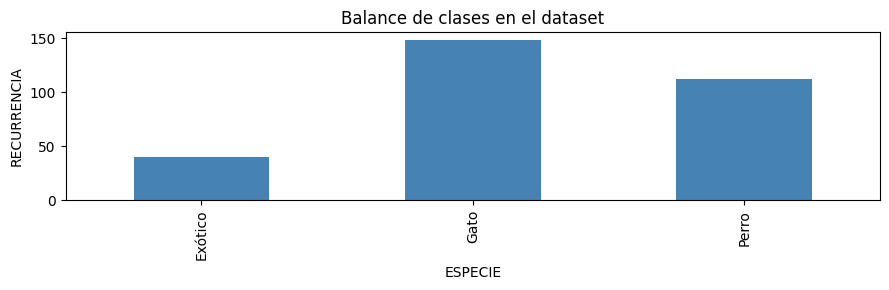


Ratio maxima/minima: 3.70
Hay desbalance. Un modelo entrenado aca aprendera sesgado hacia la clase mayoritaria.


In [84]:
import matplotlib.pyplot as plt

counts = df['especie'].value_counts().sort_index()
print("promediar")
print(counts)

plt.figure(figsize=(9,3))
counts.plot(kind='bar', color='steelblue')
plt.title("Balance de clases en el dataset")
plt.xlabel("ESPECIE")
plt.ylabel("RECURRENCIA")
plt.tight_layout()
plt.show()

ratio = counts.max() / counts.min()
print(f"\nRatio maxima/minima: {ratio:.2f}")
if ratio > 2:
    print("Hay desbalance. Un modelo entrenado aca aprendera sesgado hacia la clase mayoritaria.")

## Paso 4 — Longitud de las reseñas por calificación

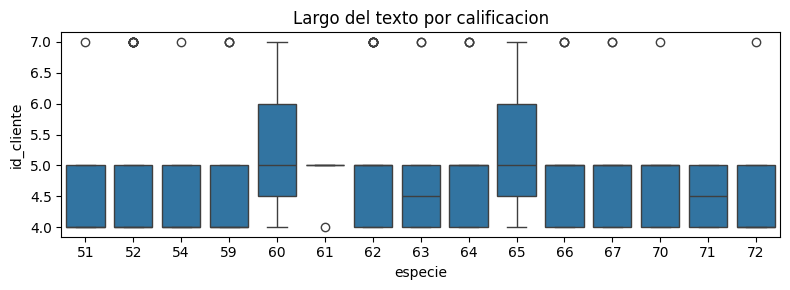

Observa: hay diferencias sistematicas de largo por categoria?
Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.


In [95]:
import seaborn as sns

df['id_cliente'] = df['especie'].str.len()

plt.figure(figsize=(8,3))
sns.boxplot(x='nota_atencion', y='resena', data=df)
plt.title("Largo del texto por calificacion")
plt.xlabel("especie")
plt.ylabel("id_cliente")
plt.tight_layout()
plt.show()

print("Observa: hay diferencias sistematicas de largo por categoria?")
print("Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.")

## Paso 5 — Valores faltantes

In [99]:
print("Valores faltantes por columna:\n")
print(df.isnull().sum())
print("\nFilas con texto vacío:", (df['nota_atencion'].fillna('') == '').sum())
print("\nDuplicados por texto (ignorando el id):", df.duplicated(subset=['id_cliente']).sum())

Valores faltantes por columna:

id_cita                   0
id_mascota                0
id_veterinario            0
fecha                     0
hora                      0
motivo                    0
estado                    0
id_cliente                0
nombre_x                  0
especie                   0
raza                      0
fecha_nacimiento          0
sexo                      0
peso_kg                   0
nombre_y                  0
apellido_mascota_dueno    0
telefono_mascota_dueno    0
email                     0
direccion                 0
nombre                    0
apellido_vet              0
especialidad              0
telefono_vet              0
nota_atencion             0
resena                    0
ESPECIE                   0
dtype: int64

Filas con texto vacío: 0

Duplicados por texto (ignorando el id): 297


## TU TURNO — bitácora

Anota en la bitácora de tu proyecto:

1. ¿Cuál es la clase más representada? ¿Cuál la menos?
2. ¿Hay patrones de largo del texto que podrían ser un sesgo?
3. ¿Cómo se ve el equilibrio de tu propio dataset comparado con éste?

## Cierre
Guarda copia (`Archivo → Guardar copia en Drive`), descargala y súbela a tu repo en `notebooks/Clase_23.ipynb`.